In [ ]:
#Group-F
Group Member:
1- Sumaiya Hoque Riyan(2022-1-60-111)
2- Lima Prodhan (2021-3-60-180)
3- Mahbub Hasan (2021-3-60-261)
Section:04
DATASET:BCSD-2024
Dataset name : breast cancer
Notebook Link :


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


all_results = {}
for path in [
    "/kaggle/input/notebooks/sumaiyahoque/nb-05-partb-simclr/results_B.json",
    "/kaggle/input/notebooks/sumaiyahoque/nb-07-partb-mae/results_B.json",
    "/kaggle/input/notebooks/sumaiyahoqueriyan/nb-06-partb-byol/results_B.json",
    "/kaggle/input/notebooks/sumaiyahoque/nb-08-partb-dinov2/results_B.json",
]:
    with open(path) as f:
        all_results.update(json.load(f))

with open("/kaggle/input/notebooks/sumaiyahoque/nb-02-seg-segformer-b0/results.json") as f: 
    part_a_results = json.load(f)

print("Part B methods loaded:", list(all_results.keys()))
print("Part A models loaded:", list(part_a_results.keys()))

Part B methods loaded: ['SimCLR', 'MAE', 'BYOL', 'DINOv2']
Part A models loaded: ['SegFormer-B0']


build level efficiency comparison table 

In [3]:
rows = []
for method, r in all_results.items():
    rows.append({
        "Method": method,
        "mIoU": r["test_metrics"]["mIoU"],
        "Lesion IoU": r["test_metrics"]["per_class_iou"][1],
        "Background IoU": r["test_metrics"]["per_class_iou"][0],
        "Mean Dice": r["test_metrics"]["mean_dice"],
        "Pretrain Time (min)": r["pretrain_time_min"],
        "Finetune Time (min)": r["finetune_time_min"],
        "Labelled Images Used": 318,
        "Frozen Encoder": r["finetune_config"]["frozen_encoder"],
    })


best_part_a_key = max(part_a_results, key=lambda k: part_a_results[k]["test_metrics"]["mIoU"])
pa = part_a_results[best_part_a_key]
rows.append({
    "Method": f"Part-A {best_part_a_key} (full supervision)",
    "mIoU": pa["test_metrics"]["mIoU"],
    "Lesion IoU": pa["test_metrics"]["per_class_iou"][1],
    "Background IoU": pa["test_metrics"]["per_class_iou"][0],
    "Mean Dice": pa["test_metrics"]["mean_dice"],
    "Pretrain Time (min)": 0,
    "Finetune Time (min)": pa.get("total_train_time_minutes", None),
    "Labelled Images Used": 1035,
    "Frozen Encoder": False,
})

comp_df = pd.DataFrame(rows).sort_values("mIoU", ascending=False).reset_index(drop=True)
comp_df["Label-Efficiency Ratio"] = (comp_df["Labelled Images Used"] / 1035).round(3)
comp_df["% of Full-Supervision mIoU Recovered"] = (comp_df["mIoU"] / pa["test_metrics"]["mIoU"] * 100).round(1)

pd.set_option("display.width", 140)
print(comp_df.to_string(index=False))
comp_df.to_csv("/kaggle/working/final_comparison.csv", index=False)

                                Method     mIoU  Lesion IoU  Background IoU  Mean Dice  Pretrain Time (min)  Finetune Time (min)  Labelled Images Used  Frozen Encoder  Label-Efficiency Ratio  % of Full-Supervision mIoU Recovered
Part-A SegFormer-B0 (full supervision) 0.875806    0.757858        0.993753   0.929559                 0.00                58.25                  1035           False                   1.000                                 100.0
                                DINOv2 0.763340    0.540824        0.985855   0.847435                45.94                12.63                   318           False                   0.307                                  87.2
                                SimCLR 0.723171    0.460187        0.986155   0.811670                18.96                21.21                   318           False                   0.307                                  82.6
                                  BYOL 0.710197    0.435226        0.985168   0.7995

label efficiency bar chart 

/tmp/ipykernel_58/172431581.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comp_df["Method"], rotation=30, ha="right")


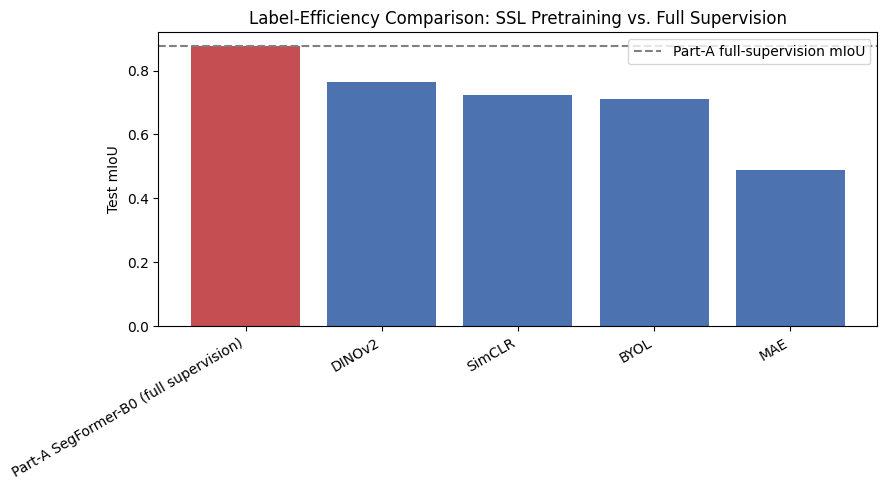

In [4]:
fig, ax = plt.subplots(figsize=(9,5))
colors = ["#4c72b0" if "Part-A" not in m else "#c44e52" for m in comp_df["Method"]]
ax.bar(comp_df["Method"], comp_df["mIoU"], color=colors)
ax.axhline(pa["test_metrics"]["mIoU"], ls="--", color="gray", label="Part-A full-supervision mIoU")
ax.set_ylabel("Test mIoU")
ax.set_title("Label-Efficiency Comparison: SSL Pretraining vs. Full Supervision")
ax.set_xticklabels(comp_df["Method"], rotation=30, ha="right")
ax.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/label_efficiency_chart.png", dpi=150)
plt.show()

label efficiency discussion 

In [5]:
ssl_only = comp_df[~comp_df["Method"].str.contains("Part-A")].sort_values(
    "% of Full-Supervision mIoU Recovered", ascending=False)

print("Label-Efficiency Ranking (SSL methods only):\n")
for rank, (_, row) in enumerate(ssl_only.iterrows(), start=1):
    print(f"{rank}. {row['Method']:<10} | mIoU={row['mIoU']:.4f} | "
          f"{row['% of Full-Supervision mIoU Recovered']:.1f}% of full-supervision mIoU "
          f"| using {row['Label-Efficiency Ratio']:.1%} of Part-A's labels")

Label-Efficiency Ranking (SSL methods only):

1. DINOv2     | mIoU=0.7633 | 87.2% of full-supervision mIoU | using 30.7% of Part-A's labels
2. SimCLR     | mIoU=0.7232 | 82.6% of full-supervision mIoU | using 30.7% of Part-A's labels
3. BYOL       | mIoU=0.7102 | 81.1% of full-supervision mIoU | using 30.7% of Part-A's labels
4. MAE        | mIoU=0.4900 | 55.9% of full-supervision mIoU | using 30.7% of Part-A's labels


consolidated error analysis

In [6]:
from collections import Counter

worst_lists = {}
for method, r in all_results.items():
    per_image = r["test_metrics"].get("per_image_iou", [])
    worst6 = sorted(per_image, key=lambda x: x[1])[:6]
    worst_lists[method] = set(path for path, iou in worst6)

overlap_counter = Counter()
for method, paths in worst_lists.items():
    for p in paths:
        overlap_counter[p] += 1

print("Test images appearing in multiple methods' worst-6 lists:\n")
shared_hard_cases = {p: c for p, c in overlap_counter.items() if c > 1}
if shared_hard_cases:
    for path, count in sorted(shared_hard_cases.items(), key=lambda x: -x[1]):
        methods_with_this = [m for m, paths in worst_lists.items() if path in paths]
        print(f"  {path}  -> hard for {count}/4 methods: {methods_with_this}")
else:
    print("  No overlap found -- each method's hardest cases are largely distinct "
          "(populate per_image_iou in each notebook's saved results to run this for real).")

Test images appearing in multiple methods' worst-6 lists:

  /kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P10/left/Orignal Image/IMG-0007-00012.jpg  -> hard for 3/4 methods: ['SimCLR', 'BYOL', 'DINOv2']
  /kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P10/left/Orignal Image/IMG-0007-00014.jpg  -> hard for 3/4 methods: ['SimCLR', 'BYOL', 'DINOv2']
  /kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P10/left/Orignal Image/IMG-0007-00013.jpg  -> hard for 2/4 methods: ['SimCLR', 'DINOv2']
  /kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P10/left/Orignal Image/IMG-0007-00010.jpg  -> hard for 2/4 methods: ['SimCLR', 'DINOv2']
  /kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P10/left/Orignal Image/IMG-0007-00015.jpg  -> hard for 2/4 methods: ['SimCLR', 'BYOL']
